# 01 — LGBM v1: Full Feature Pool with Boruta Selection

**Architecture:** LightGBM binary classifier, M1Y expanding walk-forward.
**Target:** `label` — 1 if next-bar close > current close (directional).
**Features:** All 285 features from `BTCUSDT_1h_unified.parquet`, reduced via
4-stage Boruta selection against the directional label on the pre-OOS window.
This includes V3 external features (fear & greed, cross-asset) not available in v12.
**Signal:** Long if P(Up) > threshold; Short if P(Up) < threshold.
**Fees:** Spot taker for long exits; futures taker for short exits; maker for TP/entries.

Outputs standard artifacts for meta-learning:
`oos_probs.npy`, `oos_index.npy`, `model.txt`, `results.json`.


In [1]:

import calendar, itertools, json, time, warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

# ── Paths ─────────────────────────────────────────────────────────────────────
def _repo_root():
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO     = _repo_root()
ARTS_DIR = REPO / 'artifacts' / 'notebooks_v2' / '01_lgbm'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
SELECTION_CACHE = ARTS_DIR / 'selected_features.json'

# ── WFO ───────────────────────────────────────────────────────────────────────
OOS_START        = pd.Timestamp('2024-01-01')
GRID_VAL_START   = pd.Timestamp('2022-01-01')
GRID_VAL_END     = pd.Timestamp('2023-12-31')
TRAIN_WINDOW_H   = 8760      # 1 year
STEP_SIZE        = 720       # monthly step
EMBARGO          = 12
VAL_FRAC         = 0.20

# ── Feature selection thresholds ──────────────────────────────────────────────
STAGE2_AUC_FLOOR  = 0.505
STAGE3_N_WINDOWS  = 3
STAGE3_MIN_WINS   = 2
STAGE3_AUC_THRESH = 0.508
BORUTA_TRIALS     = 40
BORUTA_ESTIMATORS = 150
BORUTA_HIT_RATE   = 0.50

# ── Columns to exclude from ML feature pool ───────────────────────────────────
EXCLUDE_FROM_ML = {
    'open', 'high', 'low', 'close', 'volume',   # raw OHLCV
    'label',                                      # target
    'sma_200',                                    # raw price level (non-stationary)
    'mkt_stablecoin_pct',                         # 11% non-null — too sparse
}

# ── Fee model ─────────────────────────────────────────────────────────────────
MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077
LABEL_COL = 'label'

# ── Backtest grid ─────────────────────────────────────────────────────────────
TRADING_GRID = {
    'long_threshold':  [0.55, 0.58, 0.60, 0.63],
    'short_threshold': [0.30, 0.35, 0.40],
    'entry_atr_mult':  [0.3,  0.6,  1.0],
    'sl_atr_mult':     [1.5,  2.0,  2.5],
    'tp_atr_mult':     [2.0,  2.5,  3.0],
    'min_sl':          [0.010, 0.015],
    'min_hold':        [4,  8],
    'max_hold':        [24, 48],
    'cooldown':        [2,  3],
}
_keys   = list(TRADING_GRID)
_combos = list(itertools.product(*TRADING_GRID.values()))
print(f'Grid: {len(_combos):,} combos')
print(f'Artifacts → {ARTS_DIR}')
print(f'Selection cache: {SELECTION_CACHE}')


Grid: 5,184 combos
Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm
Selection cache: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm/selected_features.json


## 1 · Load unified parquet

In [2]:

UNIFIED = REPO / 'data' / 'features' / 'BTCUSDT_1h_unified.parquet'
if not UNIFIED.exists():
    raise FileNotFoundError(f'{UNIFIED} — run 00_data_ingestion_v1.ipynb first.')

df = pd.read_parquet(UNIFIED)
df.index = df.index.tz_localize(None) if df.index.tz else df.index

# All candidate features (everything except excluded set)
ALL_CANDIDATES = sorted([
    c for c in df.columns
    if c not in EXCLUDE_FROM_ML
    and pd.api.types.is_numeric_dtype(df[c])
])

oos_mask = df.index >= OOS_START
sel_mask = df.index < OOS_START   # selection window = pre-OOS

print(f'Unified parquet : {df.shape}  ({df.index.min().date()} → {df.index.max().date()})')
print(f'Feature candidates: {len(ALL_CANDIDATES)}')
print(f'OOS bars        : {oos_mask.sum():,}  ({OOS_START.date()} → {df.index[-1].date()})')
print(f'Label dist      : {df[LABEL_COL].value_counts().to_dict()}')
print(f'Fear/greed non-null: {df["sent_fear_greed"].notna().mean():.1%}')


Unified parquet : (74366, 292)  (2017-11-15 → 2026-05-16)
Feature candidates: 284
OOS bars        : 20,785  (2024-01-01 → 2026-05-16)
Label dist      : {1: 37822, 0: 36544}
Fear/greed non-null: 97.5%


## 2 · Feature selection (4-stage Boruta)

All stages use only pre-OOS data to prevent any look-ahead.

| Stage | Method | Criterion |
|-------|--------|-----------|
| 1 | Variance drop + Spearman collinearity | var > 1e-6; ρ < 0.85 |
| 2 | Univariate AUC vs directional label | AUC ≥ 0.505 (either direction) |
| 3 | Rolling AUC stability across 3 sub-windows | AUC > 0.508 in ≥ 2/3 windows |
| 4 | Boruta-LGBM shadow feature test | hit rate > 50% over 40 trials |


In [3]:

if SELECTION_CACHE.exists():
    with open(SELECTION_CACHE) as f:
        _cached = json.load(f)
    SELECTED_FEATURES = _cached['selected']
    print(f'Loaded {len(SELECTED_FEATURES)} features from cache ({SELECTION_CACHE.name})')
    print(f'Stage sizes: {_cached["stage_sizes"]}')
    print(f'Features: {SELECTED_FEATURES}')
else:
    df_sel = df[sel_mask][ALL_CANDIDATES].fillna(0)
    y_sel  = df[sel_mask][LABEL_COL].values.astype(int)
    X      = df_sel.values.astype(np.float32)
    cols   = list(df_sel.columns)
    n0     = len(cols)

    # ── Stage 1: Variance + Spearman collinearity ──────────────────────────
    print('Stage 1: variance drop + Spearman collinearity ...')
    t0 = time.time()
    vm = X.var(0) > 1e-6
    cols = [c for c, v in zip(cols, vm) if v]; X = X[:, vm]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        corr, _ = spearmanr(X)
    corr = np.abs(np.array(corr if X.shape[1] > 1 else [[0]]))
    np.fill_diagonal(corr, 0)
    drop = set()
    for i in range(len(cols)):
        if i in drop: continue
        for j in range(i+1, len(cols)):
            if j not in drop and corr[i,j] > 0.85: drop.add(j)
    cols = [c for i,c in enumerate(cols) if i not in drop]
    X    = X[:, [i for i in range(X.shape[1]) if i not in drop]]
    n1   = len(cols)
    print(f'  {n0} → {n1}  ({time.time()-t0:.1f}s)')

    # ── Stage 2: Univariate AUC ────────────────────────────────────────────
    print(f'Stage 2: univariate AUC ≥ {STAGE2_AUC_FLOOR} ...')
    t0 = time.time()
    aucs = []
    for j in range(X.shape[1]):
        try: a = roc_auc_score(y_sel, X[:,j]); aucs.append(max(a, 1-a))
        except: aucs.append(0.5)
    aucs = np.array(aucs)
    keep = aucs >= STAGE2_AUC_FLOOR
    cols = [c for c,k in zip(cols,keep) if k]; X = X[:,keep]
    n2   = len(cols)
    print(f'  {n1} → {n2}  (AUC p50={np.median(aucs):.4f}  max={aucs.max():.4f})  ({time.time()-t0:.1f}s)')

    # ── Stage 3: Rolling AUC stability ────────────────────────────────────
    print(f'Stage 3: rolling AUC stability ({STAGE3_N_WINDOWS} windows, ≥{STAGE3_MIN_WINS} pass) ...')
    t0 = time.time()
    n_s = len(X); win = n_s // STAGE3_N_WINDOWS
    hits = np.zeros(len(cols), dtype=int)
    for w in range(STAGE3_N_WINDOWS):
        sl = slice(w*win, (w+1)*win if w < STAGE3_N_WINDOWS-1 else n_s)
        Xw, yw = X[sl], y_sel[sl]
        if len(np.unique(yw)) < 2: continue
        for j in range(Xw.shape[1]):
            try:
                a = roc_auc_score(yw, Xw[:,j])
                if max(a, 1-a) >= STAGE3_AUC_THRESH: hits[j] += 1
            except: pass
    stable = hits >= STAGE3_MIN_WINS
    cols = [c for c,s in zip(cols,stable) if s]; X = X[:,stable]
    n3   = len(cols)
    print(f'  {n2} → {n3}  ({time.time()-t0:.1f}s)')

    # ── Stage 4: Boruta ────────────────────────────────────────────────────
    print(f'Stage 4: Boruta ({BORUTA_TRIALS} trials × {BORUTA_ESTIMATORS} trees) ...')
    t0 = time.time()
    rng = np.random.default_rng(42)
    hit_counts = np.zeros(len(cols))
    for trial in range(BORUTA_TRIALS):
        Xs = X.copy()
        for j in range(Xs.shape[1]): rng.shuffle(Xs[:,j])
        model = lgb.LGBMClassifier(
            n_estimators=BORUTA_ESTIMATORS, num_leaves=31, learning_rate=0.05,
            subsample=0.7, colsample_bytree=0.7, min_child_samples=20,
            verbose=-1, n_jobs=-1, random_state=int(trial),
        )
        model.fit(np.hstack([X, Xs]), y_sel)
        imp = model.feature_importances_
        nf  = len(cols)
        hit_counts += (imp[:nf] > imp[nf:].max()).astype(float)
        if (trial+1) % 10 == 0:
            print(f'  trial {trial+1}/{BORUTA_TRIALS}  confirmed so far: '
                  f'{(hit_counts/(trial+1) > BORUTA_HIT_RATE).sum()}')

    hit_rate = hit_counts / BORUTA_TRIALS
    SELECTED_FEATURES = [c for c,r in zip(cols,hit_rate) if r > BORUTA_HIT_RATE]
    n4 = len(SELECTED_FEATURES)
    print(f'  {n3} → {n4}  ({time.time()-t0:.1f}s)')

    cache_data = {
        'selected': SELECTED_FEATURES,
        'hit_rates': {c: round(float(r),4) for c,r in zip(cols, hit_rate)},
        'stage_sizes': [n0, n1, n2, n3, n4],
        'exclude_from_ml': sorted(EXCLUDE_FROM_ML),
    }
    with open(SELECTION_CACHE, 'w') as f:
        json.dump(cache_data, f, indent=2)
    print(f'Saved → {SELECTION_CACHE}')

    print(f'\nSelected {len(SELECTED_FEATURES)} features:')
    for f_ in sorted(SELECTED_FEATURES): print(f'  {f_}')

miss = [f for f in SELECTED_FEATURES if f not in df.columns]
print(f'Missing features: {miss if miss else "none ✓"}')


Stage 1: variance drop + Spearman collinearity ...
  284 → 162  (0.6s)
Stage 2: univariate AUC ≥ 0.505 ...
  162 → 51  (AUC p50=0.5031  max=0.5609)  (0.7s)
Stage 3: rolling AUC stability (3 windows, ≥2 pass) ...
  51 → 37  (0.3s)
Stage 4: Boruta (40 trials × 150 trees) ...
  trial 10/40  confirmed so far: 11
  trial 20/40  confirmed so far: 11
  trial 30/40  confirmed so far: 11
  trial 40/40  confirmed so far: 11
  37 → 11  (44.4s)
Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm/selected_features.json

Selected 11 features:
  bb_position_20
  close_vs_ema_7
  close_vs_kijun
  close_vs_true_vwap
  cross_btc_relative_strength
  hour_sin
  liq_vwap_dev_daily
  log_ret_2h
  lower_wick
  mkt_total_mcap_chg_24h
  rsi_vol_confirm
Missing features: none ✓


## 3 · Feature importance: Boruta hit rates

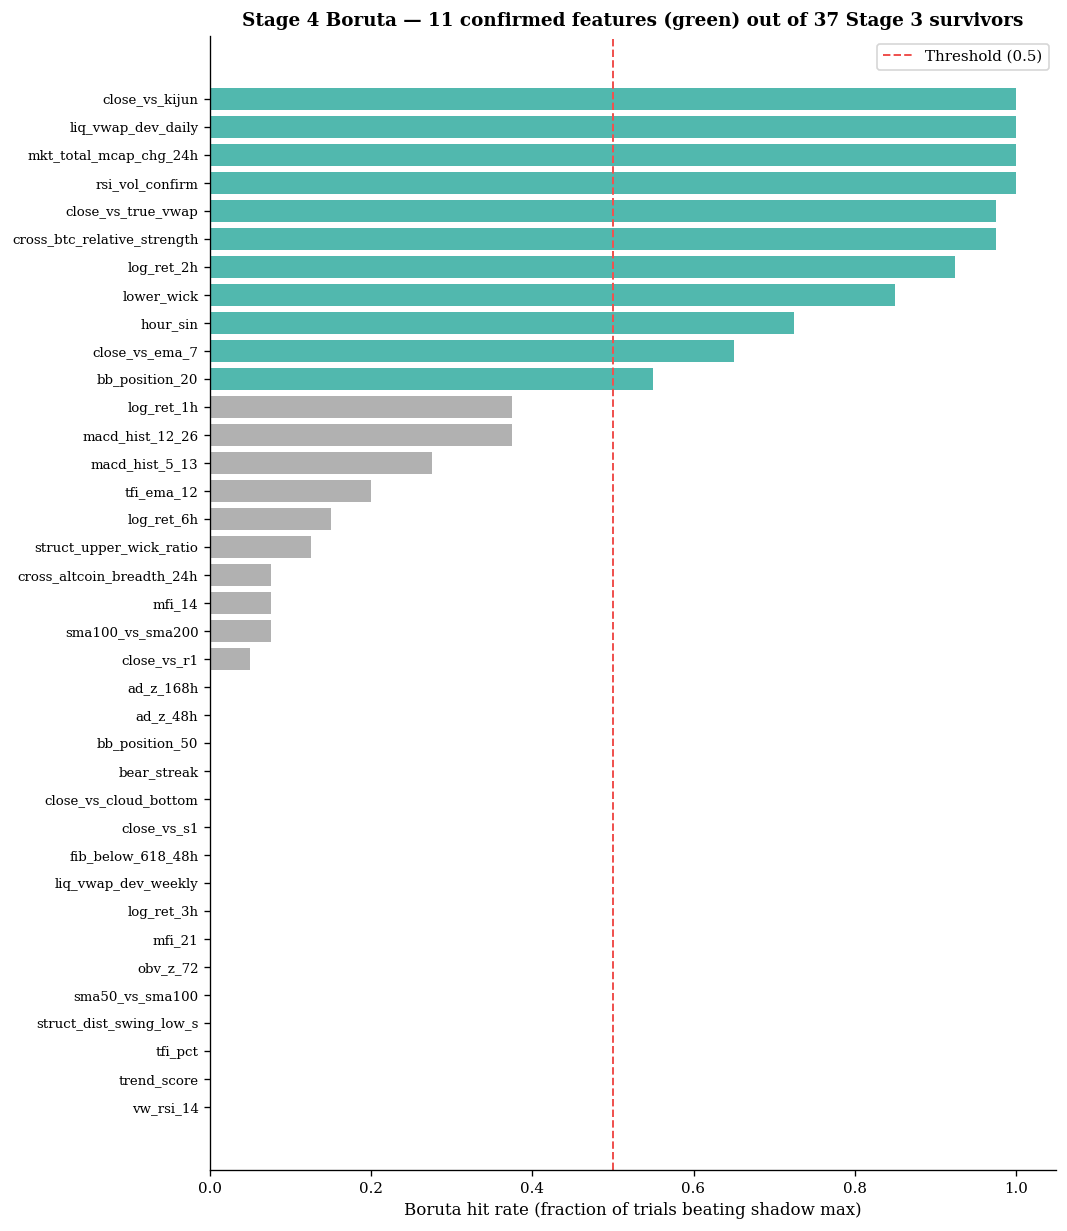

In [4]:

if SELECTION_CACHE.exists():
    with open(SELECTION_CACHE) as f:
        sel_data = json.load(f)
    hit_rates = sel_data.get('hit_rates', {})
    if hit_rates:
        feat_hr = sorted(hit_rates.items(), key=lambda t: t[1], reverse=True)
        names_hr, rates_hr = zip(*feat_hr)
        colors_hr = [GREEN if r > BORUTA_HIT_RATE else GREY for r in rates_hr]
        fig, ax = plt.subplots(figsize=(9, max(5, len(feat_hr)*0.28)))
        ax.barh(range(len(feat_hr)), rates_hr, color=colors_hr, alpha=0.8)
        ax.set_yticks(range(len(feat_hr)))
        ax.set_yticklabels(names_hr, fontsize=8)
        ax.invert_yaxis()
        ax.axvline(BORUTA_HIT_RATE, color=RED, ls='--', lw=1.2,
                   label=f'Threshold ({BORUTA_HIT_RATE})')
        ax.set_xlabel('Boruta hit rate (fraction of trials beating shadow max)')
        ax.set_title(f'Stage 4 Boruta — {len(SELECTED_FEATURES)} confirmed features '
                     f'(green) out of {len(feat_hr)} Stage 3 survivors', fontweight='bold')
        ax.legend()
        fig.tight_layout(); fig.savefig(ARTS_DIR/'00_boruta_hit_rates.png'); plt.show()


## 4 · M1Y walk-forward training

In [5]:

LGBM_PARAMS = dict(
    num_leaves=31, max_depth=6, learning_rate=0.05,
    colsample_bytree=0.5, min_child_samples=50, subsample=0.7,
    reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
    objective='binary', metric='auc', verbose=-1, random_state=42,
)

def run_m1y_wfo(df, verbose=True):
    n = len(df); probs = np.full(n, np.nan)
    i = 0; steps = 0; last_model = None
    while i < n:
        tr_end = i; tr_start = max(0, tr_end - TRAIN_WINDOW_H)
        if tr_start >= tr_end - 100: i += STEP_SIZE; continue
        sl = df.iloc[tr_start:tr_end]
        val_n = max(50, int(len(sl) * VAL_FRAC))
        X_tr = sl.iloc[:-val_n][SELECTED_FEATURES].fillna(0).values
        y_tr = sl.iloc[:-val_n][LABEL_COL].values
        X_va = sl.iloc[-val_n:][SELECTED_FEATURES].fillna(0).values
        y_va = sl.iloc[-val_n:][LABEL_COL].values
        if len(np.unique(y_tr)) < 2: i += STEP_SIZE; continue
        mdl = lgb.LGBMClassifier(**LGBM_PARAMS)
        mdl.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        oos_end = min(i + STEP_SIZE, n); oos_emb = min(i + EMBARGO, oos_end)
        X_oos = df.iloc[oos_emb:oos_end][SELECTED_FEATURES].fillna(0).values
        if len(X_oos): probs[oos_emb:oos_end] = mdl.predict_proba(X_oos)[:, 1]
        last_model = mdl; steps += 1
        if verbose and steps % 6 == 1:
            print(f'  Step {steps:>3}  [{df.index[tr_start].date()} → '
                  f'{df.index[tr_end-1].date()}]  OOS [{df.index[oos_emb].date()} → '
                  f'{df.index[oos_end-1].date()}]')
        i += STEP_SIZE
    return pd.Series(probs, index=df.index, name='p_up'), last_model

t0 = time.time()
all_probs, last_model = run_m1y_wfo(df)
print(f'WFO done in {(time.time()-t0)/60:.1f} min  |  features: {len(SELECTED_FEATURES)}')

gv_mask   = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
oos_probs = all_probs[oos_mask]

valid_oos = ~np.isnan(oos_probs.values)
oos_df    = df[oos_mask].copy()
auc_oos   = roc_auc_score(oos_df[LABEL_COL].values[valid_oos], oos_probs.values[valid_oos])
print(f'OOS AUC: {auc_oos:.4f}  ({OOS_START.date()} → {oos_df.index[-1].date()})')


  Step   1  [2017-11-15 → 2017-12-15]  OOS [2017-12-15 → 2018-01-14]
  Step   7  [2017-11-15 → 2018-06-14]  OOS [2018-06-15 → 2018-07-15]
  Step  13  [2017-12-10 → 2018-12-12]  OOS [2018-12-13 → 2019-01-11]
  Step  19  [2018-06-09 → 2019-06-11]  OOS [2019-06-12 → 2019-07-11]
  Step  25  [2018-12-07 → 2019-12-09]  OOS [2019-12-09 → 2020-01-08]
  Step  31  [2019-06-06 → 2020-06-06]  OOS [2020-06-07 → 2020-07-06]
  Step  37  [2019-12-04 → 2020-12-03]  OOS [2020-12-04 → 2021-01-02]
  Step  43  [2020-06-01 → 2021-06-02]  OOS [2021-06-02 → 2021-07-02]
  Step  49  [2020-11-28 → 2021-11-29]  OOS [2021-11-29 → 2021-12-29]
  Step  55  [2021-05-28 → 2022-05-28]  OOS [2022-05-28 → 2022-06-27]
  Step  61  [2021-11-24 → 2022-11-24]  OOS [2022-11-24 → 2022-12-24]
  Step  67  [2022-05-23 → 2023-05-23]  OOS [2023-05-23 → 2023-06-22]
  Step  73  [2022-11-19 → 2023-11-19]  OOS [2023-11-19 → 2023-12-19]
  Step  79  [2023-05-18 → 2024-05-17]  OOS [2024-05-17 → 2024-06-16]
  Step  85  [2023-11-14 → 2024-11-

## 5 · Permutation importance (last WFO fold)

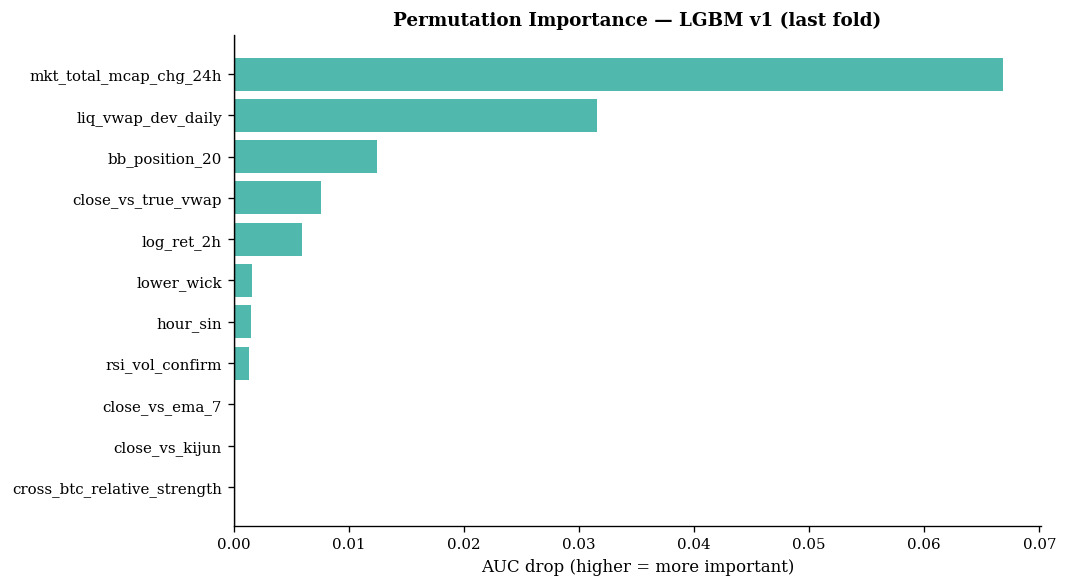

Top 10: ['mkt_total_mcap_chg_24h', 'liq_vwap_dev_daily', 'bb_position_20', 'close_vs_true_vwap', 'log_ret_2h', 'lower_wick', 'hour_sin', 'rsi_vol_confirm', 'close_vs_ema_7', 'close_vs_kijun']


In [6]:

# Quick permutation importance on the last-fold validation data
if last_model is not None:
    # Use the last 2 years as a held-out importance window
    imp_mask = (df.index >= pd.Timestamp('2022-01-01')) & (df.index < OOS_START)
    X_imp = df[imp_mask][SELECTED_FEATURES].fillna(0).values
    y_imp = df[imp_mask][LABEL_COL].values

    base_auc = roc_auc_score(y_imp, last_model.predict_proba(X_imp)[:,1])
    perm_imp = {}
    rng = np.random.default_rng(99)
    for fi, feat in enumerate(SELECTED_FEATURES):
        drops = []
        for _ in range(3):
            Xp = X_imp.copy(); rng.shuffle(Xp[:, fi])
            drops.append(base_auc - roc_auc_score(y_imp, last_model.predict_proba(Xp)[:,1]))
        perm_imp[feat] = float(np.mean(drops))

    sf = sorted(perm_imp, key=perm_imp.get, reverse=True)
    fig, ax = plt.subplots(figsize=(9, max(5, len(sf)*0.35)))
    ax.barh(range(len(sf)), [perm_imp[f] for f in sf],
            color=[GREEN if perm_imp[f]>0 else RED for f in sf], alpha=0.8)
    ax.set_yticks(range(len(sf))); ax.set_yticklabels(sf, fontsize=9); ax.invert_yaxis()
    ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('AUC drop (higher = more important)')
    ax.set_title('Permutation Importance — LGBM v1 (last fold)', fontweight='bold')
    fig.tight_layout(); fig.savefig(ARTS_DIR/'01_perm_importance.png'); plt.show()
    print('Top 10:', sf[:10])
else:
    perm_imp = {}
    print('No model available for importance analysis.')


## 6 · Grid search (2022–2023 validation window)

In [7]:

def _run_backtest(probs_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_sl, min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=pos_eq=entry_fee=0.0
    hold_cnt=cd_cnt=0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.; reason=''; exit_fee=0.
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)+funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long': filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else: filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif not np.isnan(probs_arr[i]) and i+1<n:
            atr=max(atr_arr[i], min_sl)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif probs_arr[i]<short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))+funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

gv_df  = df[gv_mask]
gv_p   = all_probs[gv_mask].values
rows   = []
t0     = time.time()
for vals in _combos:
    p = dict(zip(_keys, vals))
    if p['short_threshold'] >= p['long_threshold'] or p['max_hold'] < p['min_hold']: continue
    eq, tr = _run_backtest(gv_p, gv_df['close'].values, gv_df['high'].values,
                           gv_df['low'].values, gv_df['atr_14_pct'].values,
                           with_fees=True, **p)
    if len(tr) < 20: continue
    rows.append({**p, 'sharpe':_sharpe(eq), 'total_ret':float(eq[-1]-1),
                 'maxdd':_maxdd(eq), 'win_rate':float(np.mean([t['net']>0 for t in tr])),
                 'n_trades':len(tr)})

grid_df = pd.DataFrame(rows).sort_values('sharpe', ascending=False).reset_index(drop=True)
INT = {'min_hold','max_hold','cooldown'}
BEST = {k:(int(grid_df.iloc[0][k]) if k in INT else float(grid_df.iloc[0][k])) for k in _keys}
print(f'Grid done in {time.time()-t0:.0f}s  |  {len(grid_df):,} valid combos')
print('Best params:'); [print(f'  {k:<18}{v}') for k,v in BEST.items()]
print(grid_df.head(5).to_string())


Grid done in 44s  |  5,184 valid combos
Best params:
  long_threshold    0.6
  short_threshold   0.4
  entry_atr_mult    0.6
  sl_atr_mult       2.5
  tp_atr_mult       2.5
  min_sl            0.01
  min_hold          4
  max_hold          24
  cooldown          2
   long_threshold  short_threshold  entry_atr_mult  sl_atr_mult  tp_atr_mult  min_sl  min_hold  max_hold  cooldown  sharpe  total_ret   maxdd  win_rate  n_trades
0          0.6000           0.4000          0.6000       2.5000       2.5000  0.0100         4        24         2  5.2415     8.8573 -0.0823    0.6965       257
1          0.6000           0.4000          0.3000       2.5000       2.5000  0.0100         4        24         2  5.1986     8.7521 -0.0881    0.6887       257
2          0.6300           0.3500          0.3000       2.5000       2.5000  0.0100         4        24         2  5.1024     5.7826 -0.0982    0.7164       201
3          0.6000           0.4000          1.0000       2.5000       2.5000  0.0100   

## 7 · OOS backtest

In [8]:

eq_fees,tdf_fees=_run_backtest(oos_probs.values, oos_df['close'].values,
    oos_df['high'].values, oos_df['low'].values, oos_df['atr_14_pct'].values,
    with_fees=True, **BEST)
eq_0fee,tdf_0fee=_run_backtest(oos_probs.values, oos_df['close'].values,
    oos_df['high'].values, oos_df['low'].values, oos_df['atr_14_pct'].values,
    with_fees=False, **BEST)
TF=pd.DataFrame(tdf_fees) if tdf_fees else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
T0=pd.DataFrame(tdf_0fee) if tdf_0fee else pd.DataFrame(columns=['direction','reason','gross','net','hold'])

bh=(oos_df['close'].values/oos_df['close'].iloc[0]-1)*100
o_idx=oos_df.index

print(f'{"":22}{"Trades":>7}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print('-'*62)
for lbl,eq,t in [('With fees',eq_fees,TF),('Zero-fee',eq_0fee,T0)]:
    wr=(t['net']>0).mean() if len(t) else 0
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    print(f'{lbl:22}{len(t):>7}  {nl}L/{ns}S  {wr:>6.1%}{eq[-1]-1:>+9.1%}{_sharpe(eq):>8.3f}{_maxdd(eq):>8.1%}')
print(f'BTC Buy & Hold                               {bh[-1]:>+9.1f}%')


                       Trades     Win   Return  Sharpe   MaxDD
--------------------------------------------------------------
With fees                 492  290L/202S   69.5% +4972.6%   5.466  -11.4%
Zero-fee                  492  290L/202S   72.2% +7116.4%   5.959  -11.2%
BTC Buy & Hold                                   +86.3%


## 8 · Figures

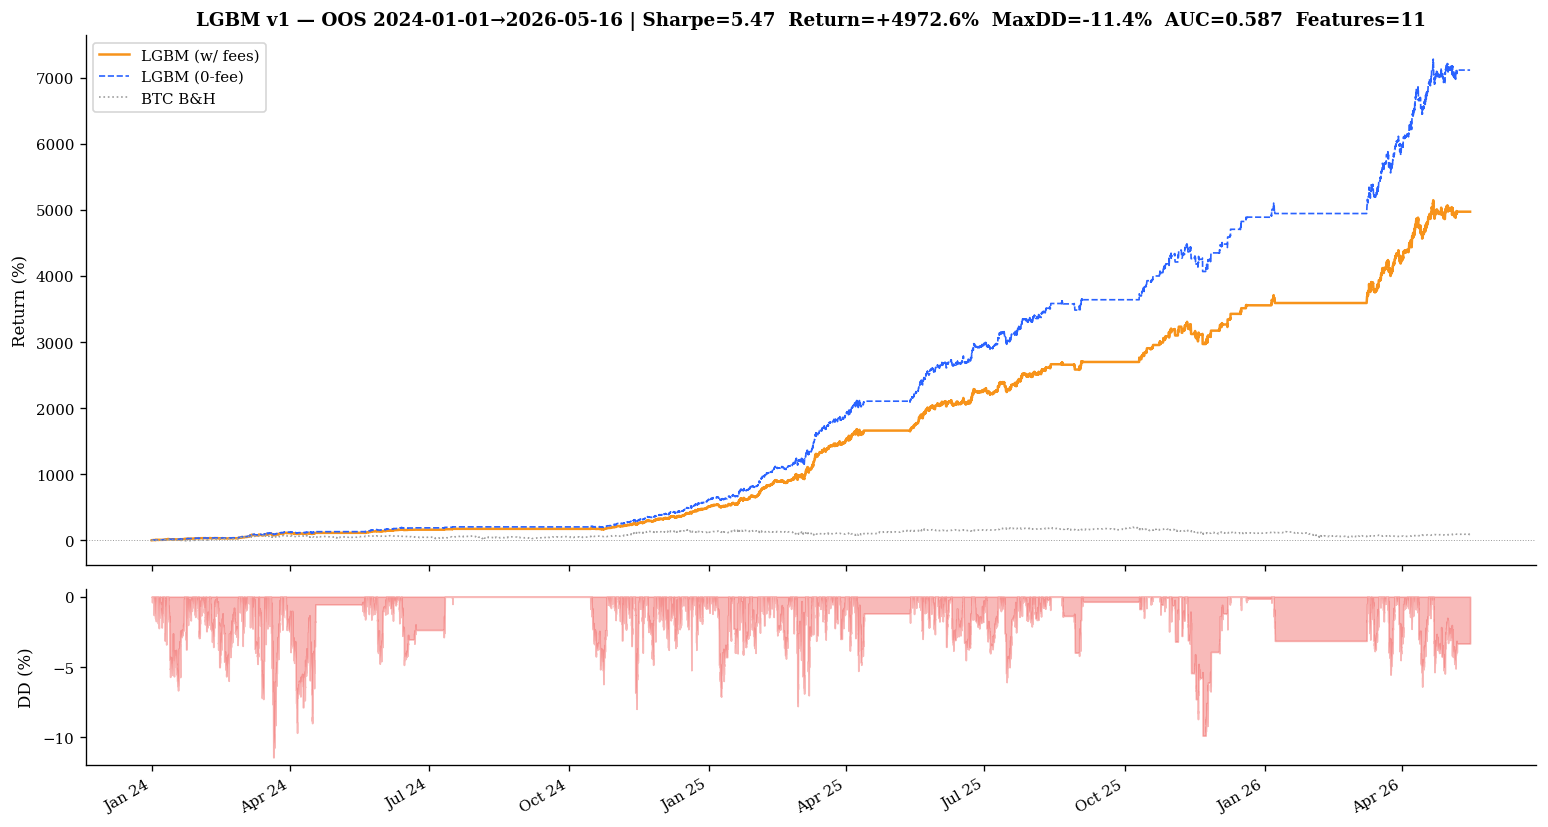

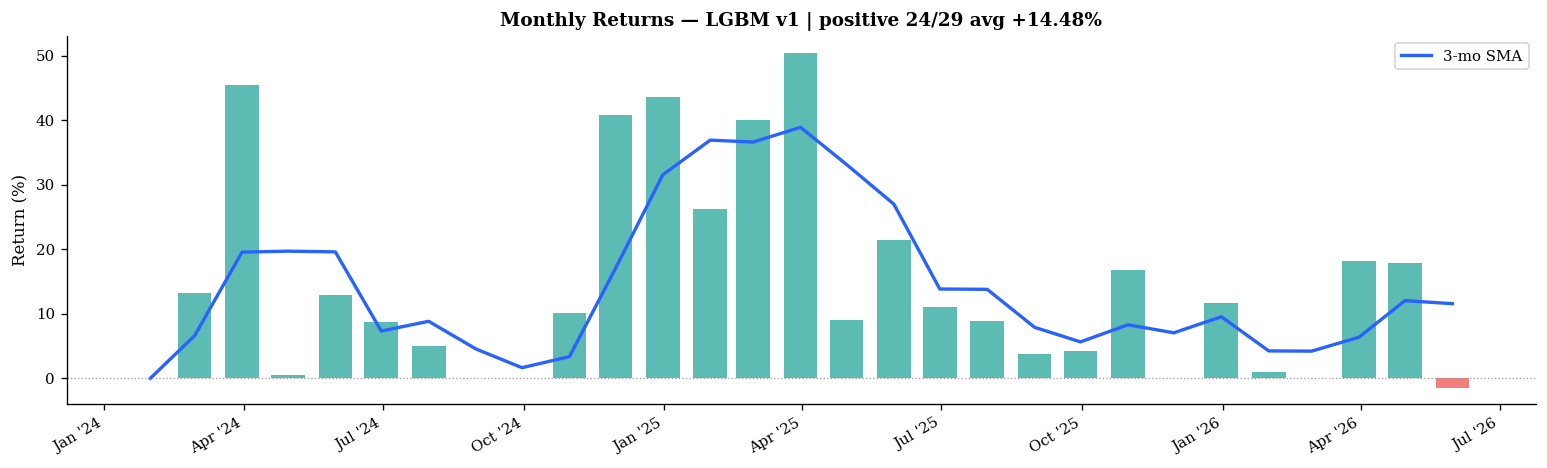

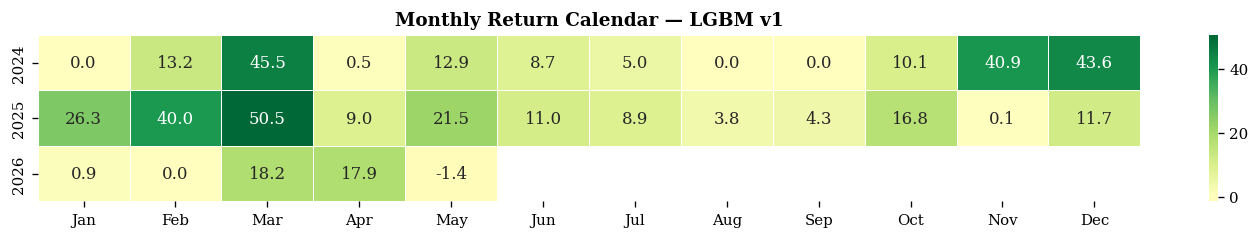

In [9]:

# Equity + drawdown
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(13,7),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='LGBM (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=1.0,ls='--',label='LGBM (0-fee)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(
    f'LGBM v1 — OOS {OOS_START.date()}→{o_idx[-1].date()} | '
    f'Sharpe={_sharpe(eq_fees):.2f}  Return={eq_fees[-1]-1:+.1%}  '
    f'MaxDD={_maxdd(eq_fees):.1%}  AUC={auc_oos:.3f}  Features={len(SELECTED_FEATURES)}',
    fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_equity_drawdown.png'); plt.show()

# Monthly returns + calendar heatmap
eqs=pd.Series(eq_fees,index=o_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(13,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns — LGBM v1 | '
             f'positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%',fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'03_monthly_returns.png'); plt.show()

cal=mret.to_frame('r'); cal['y']=cal.index.year; cal['m']=cal.index.month
piv=cal.pivot(index='y',columns='m',values='r')
piv.columns=[calendar.month_abbr[m] for m in piv.columns]
fig,ax=plt.subplots(figsize=(12,max(2,len(piv)*0.7)))
sns.heatmap(piv,ax=ax,cmap='RdYlGn',center=0,annot=True,fmt='.1f',linewidths=0.5)
ax.set_title('Monthly Return Calendar — LGBM v1',fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel(''); fig.tight_layout()
fig.savefig(ARTS_DIR/'04_monthly_heatmap.png'); plt.show()


## 9 · Save artifacts

In [10]:

# Standard artifacts for meta-learning
np.save(ARTS_DIR/'oos_probs.npy', oos_probs.values.astype(np.float32))
np.save(ARTS_DIR/'oos_index.npy', oos_df.index.astype(np.int64).values)

if last_model is not None:
    last_model.booster_.save_model(str(ARTS_DIR/'model.txt'))

def _bt_metrics(eq, t):
    wr=float((t['net']>0).mean()) if len(t) else 0.
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    return {'n_trades':len(t),'n_long':nl,'n_short':ns,'win_rate':round(wr,4),
            'total_ret':round(float(eq[-1]-1),4),'sharpe':round(_sharpe(eq),4),
            'maxdd':round(_maxdd(eq),4)}

results = {
    'notebook': '01_lgbm_v1',
    'created': pd.Timestamp.now().isoformat(),
    'model': 'LightGBM binary (directional label)',
    'feature_selection': {
        'method': '4-stage Boruta against directional label, pre-OOS',
        'n_candidates': len(ALL_CANDIDATES),
        'n_selected': len(SELECTED_FEATURES),
        'includes_v3_external': True,
        'cache': str(SELECTION_CACHE),
    },
    'wfo': {'train_window_h':TRAIN_WINDOW_H,'step_size':STEP_SIZE,'embargo':EMBARGO},
    'grid_val_window': f'{GRID_VAL_START.date()}→{GRID_VAL_END.date()}',
    'oos_period': f'{OOS_START.date()}→{oos_df.index[-1].date()}',
    'oos_auc': round(float(auc_oos), 4),
    'selected_features': SELECTED_FEATURES,
    'best_params': BEST,
    'backtest_wfees': _bt_metrics(eq_fees, TF),
    'backtest_0fee':  _bt_metrics(eq_0fee, T0),
    'monthly': {
        'mean_pct': round(float(mret.mean()),3),
        'positive_months': int((mret>0).sum()),
        'total_months': int(len(mret)),
    },
    'permutation_importance': perm_imp,
    'artifacts': {
        'oos_probs': 'oos_probs.npy',
        'oos_index': 'oos_index.npy',
        'model': 'model.txt',
        'selection_cache': 'selected_features.json',
    },
}
with open(ARTS_DIR/'results.json','w') as f:
    json.dump(results, f, indent=2)
print(f'Artifacts saved → {ARTS_DIR}')
print(json.dumps({k:v for k,v in results.items()
                  if k not in ('selected_features','permutation_importance')},indent=2))


Artifacts saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm
{
  "notebook": "01_lgbm_v1",
  "created": "2026-06-06T20:44:41.167104",
  "model": "LightGBM binary (directional label)",
  "feature_selection": {
    "method": "4-stage Boruta against directional label, pre-OOS",
    "n_candidates": 284,
    "n_selected": 11,
    "includes_v3_external": true,
    "cache": "/Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm/selected_features.json"
  },
  "wfo": {
    "train_window_h": 8760,
    "step_size": 720,
    "embargo": 12
  },
  "grid_val_window": "2022-01-01\u21922023-12-31",
  "oos_period": "2024-01-01\u21922026-05-16",
  "oos_auc": 0.5875,
  "best_params": {
    "long_threshold": 0.6,
    "short_threshold": 0.4,
    "entry_atr_mult": 0.6,
    "sl_atr_mult": 2.5,
    "tp_atr_mult": 2.5,
    "min_sl": 0.01,
    "min_hold": 4,
    "max_hold": 24,
    "cooldown": 2
  },
  "backtest_wf